# 02 — MobileNetV3Small (Lightweight Baseline)
**BTL IS54A — Người 2**

Notebook train MobileNetV3Small theo chiến lược Transfer Learning 2 giai đoạn:
- **Phase 1**: Pre-train trên AffectNet (8 lớp cảm xúc, subset 1500/class)
- **Phase 2**: Fine-tune trên Student Engagement Dataset (6 lớp trạng thái)

Mỗi phase gồm 2 stage: Freeze backbone (5 epochs, lr=1e-3) → Unfreeze (10 epochs, lr=1e-5).

**Yêu cầu:** GPU T4 (Colab Free), runtime ~50–55 phút.

---
**Output deliverables:**
- `BTL/weights/mobilenetv3_phase1.h5`
- `BTL/weights/mobilenetv3_phase2.h5`
- `BTL/results/mobilenetv3_metrics.json`
- `BTL/results/mobilenetv3_confusion_matrix.png`

## Cell 1 — Setup (Mount Drive, install MTCNN)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install mtcnn -q

import sys
sys.path.append('/content/drive/MyDrive/ProjectBTL/BTL/data')
sys.path.append('/content/drive/MyDrive/ProjectBTL/BTL/models')

import tensorflow as tf
print(f'TF version : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.0 MB/s eta 0:00:00
TF version : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Đường dẫn + Import

In [2]:
# ── Đường dẫn ────────────────────────────────────────────────────
AFFECTNET_DIR = '/content/drive/MyDrive/ProjectBTL/AffectNet'
DATA_DIR      = '/content/drive/MyDrive/ProjectBTL/BTL/data'
WEIGHTS_DIR   = '/content/drive/MyDrive/ProjectBTL/BTL/weights'
RESULTS_DIR   = '/content/drive/MyDrive/ProjectBTL/BTL/results'

# ── Import pipeline từ Người 1 ───────────────────────────────────
from preprocess import init_mtcnn
init_mtcnn()  # khởi tạo MTCNN cho Student Dataset

from dataset_affectnet import build_affectnet_dataset
from dataset_student   import build_student_dataset

# ── Import model + helpers ───────────────────────────────────────
from mobilenetv3 import (
    build_model,
    freeze_backbone,
    unfreeze_backbone,
    load_phase1_weights_for_phase2,
)

print('Imports OK')

[preprocess] MTCNN khởi tạo thành công.
Imports OK


In [3]:
import shutil, os

print('Copying AffectNet → /content/affectnet_local/ ...')
if not os.path.exists('/content/affectnet_local'):
    shutil.copytree(AFFECTNET_DIR, '/content/affectnet_local')
    print('Copy xong!')
else:
    print('Đã tồn tại, bỏ qua copy.')

# In dung lượng (chạy lệnh shell riêng dòng)
!du -sh /content/affectnet_local

# Đổi đường dẫn
AFFECTNET_DIR = '/content/affectnet_local'
print(f'AFFECTNET_DIR = {AFFECTNET_DIR}')

Copying AffectNet → /content/affectnet_local/ ...
Copy xong!
388M	/content/affectnet_local
AFFECTNET_DIR = /content/affectnet_local


---
# 🚀 PHASE 1 — Pre-train trên AffectNet (8 class)

## Cell 3 — Build dataset Phase 1

In [4]:
train_ds, class_weights = build_affectnet_dataset(
    split='train',
    data_dir=AFFECTNET_DIR,
    batch_size=32,
    subset_per_class=1500   # Colab Free — vừa quota
)
test_ds, _ = build_affectnet_dataset(
    split='test', data_dir=AFFECTNET_DIR, batch_size=32
)

print('\nclass_weights (xử lý imbalance):')
for idx, w in sorted(class_weights.items()):
    print(f'  Class {idx}: weight = {w:.4f}')

[dataset_affectnet] train: 11729 ảnh
[dataset_affectnet] test: 14518 ảnh

class_weights (xử lý imbalance):
  Class 0: weight = 0.9774
  Class 1: weight = 0.9774
  Class 2: weight = 1.1929
  Class 3: weight = 0.9774
  Class 4: weight = 0.9774
  Class 5: weight = 0.9774
  Class 6: weight = 0.9774
  Class 7: weight = 0.9774


## Cell 4 — Build model + Freeze backbone

In [5]:
model_p1 = build_model(num_classes=8)
freeze_backbone(model_p1)

model_p1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_p1.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[mobilenetv3] Backbone FROZEN — trainable params: 149,768


Model: "MobileNetV3Small_FER_8cls"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088,888 (4.15 MB)

 Trainable params: 149,768 (585.03 KB)

 Non-trainable params: 939,120 (3.58 MB)

## Cell 5 — Train Phase 1 (Freeze stage, 5 epochs)

In [6]:
history_p1_freeze = model_p1.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', patience=2, factor=0.5, verbose=1
        ),
    ],
    verbose=1
)

print(f"\nFreeze stage final val_accuracy: {history_p1_freeze.history['val_accuracy'][-1]:.4f}")

Epoch 1/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 156s 370ms/step - accuracy: 0.2540 - loss: 1.9005 - val_accuracy: 0.3676 - val_loss: 1.6500 - learning_rate: 0.0010
Epoch 2/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 115s 314ms/step - accuracy: 0.3084 - loss: 1.7467 - val_accuracy: 0.3616 - val_loss: 1.6603 - learning_rate: 0.0010
Epoch 3/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 114s 311ms/step - accuracy: 0.3180 - loss: 1.7185 - val_accuracy: 0.3880 - val_loss: 1.6036 - learning_rate: 0.0010
Epoch 4/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 118s 321ms/step - accuracy: 0.3308 - loss: 1.6973 - val_accuracy: 0.3868 - val_loss: 1.5949 - learning_rate: 0.0010
Epoch 5/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 140s 382ms/step - accuracy: 0.3478 - loss: 1.6751 - val_accuracy: 0.3972 - val_loss: 1.6012 - learning_rate: 0.0010

Freeze stage final val_accuracy: 0.3972


## Cell 6 — Unfreeze + Train Phase 1 (10 epochs, lr=1e-5)

In [7]:
unfreeze_backbone(model_p1)

model_p1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lr nhỏ hơn 100×
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_p1_unfreeze = model_p1.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'{WEIGHTS_DIR}/mobilenetv3_phase1.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', patience=2, factor=0.5, verbose=1
        ),
    ],
    verbose=1
)

print(f"\n✅ Phase 1 hoàn thành. Best val_accuracy: "
      f"{max(history_p1_unfreeze.history['val_accuracy']):.4f}")
print(f"Đã lưu weights: {WEIGHTS_DIR}/mobilenetv3_phase1.h5")

[mobilenetv3] Backbone UNFROZEN — trainable params: 1,076,776
Epoch 1/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.2660 - loss: 2.1273
Epoch 1: val_accuracy improved from None to 0.40942, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5



Epoch 1: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 214s 442ms/step - accuracy: 0.2968 - loss: 1.8806 - val_accuracy: 0.4094 - val_loss: 1.5380 - learning_rate: 1.0000e-05
Epoch 2/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.3510 - loss: 1.5814
Epoch 2: val_accuracy improved from 0.40942 to 0.43195, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5



Epoch 2: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 127s 347ms/step - accuracy: 0.3580 - loss: 1.5612 - val_accuracy: 0.4319 - val_loss: 1.5037 - learning_rate: 1.0000e-05
Epoch 3/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.3832 - loss: 1.4932
Epoch 3: val_accuracy improved from 0.43195 to 0.44896, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5



Epoch 3: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 141s 345ms/step - accuracy: 0.3832 - loss: 1.4842 - val_accuracy: 0.4490 - val_loss: 1.4728 - learning_rate: 1.0000e-05
Epoch 4/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.4000 - loss: 1.4681
Epoch 4: val_accuracy improved from 0.44896 to 0.46453, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5



Epoch 4: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 151s 413ms/step - accuracy: 0.4073 - loss: 1.4427 - val_accuracy: 0.4645 - val_loss: 1.4606 - learning_rate: 1.0000e-05
Epoch 5/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.4188 - loss: 1.4161
Epoch 5: val_accuracy improved from 0.46453 to 0.47362, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5


...


Epoch 6: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 132s 361ms/step - accuracy: 0.4312 - loss: 1.3923 - val_accuracy: 0.4837 - val_loss: 1.4525 - learning_rate: 1.0000e-05
Epoch 7/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.4409 - loss: 1.3683
Epoch 7: val_accuracy improved from 0.48368 to 0.49111, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5



Epoch 7: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 129s 352ms/step - accuracy: 0.4443 - loss: 1.3648 - val_accuracy: 0.4911 - val_loss: 1.4481 - learning_rate: 1.0000e-05
Epoch 8/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.4473 - loss: 1.3493
Epoch 8: val_accuracy improved from 0.49111 to 0.50131, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5



Epoch 8: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 127s 345ms/step - accuracy: 0.4518 - loss: 1.3420 - val_accuracy: 0.5013 - val_loss: 1.4373 - learning_rate: 1.0000e-05
Epoch 9/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.4591 - loss: 1.3150
Epoch 9: val_accuracy improved from 0.50131 to 0.50703, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5



Epoch 9: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 165s 407ms/step - accuracy: 0.4627 - loss: 1.3165 - val_accuracy: 0.5070 - val_loss: 1.4292 - learning_rate: 1.0000e-05
Epoch 10/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.4843 - loss: 1.2968
Epoch 10: val_accuracy improved from 0.50703 to 0.51557, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5



Epoch 10: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 131s 357ms/step - accuracy: 0.4833 - loss: 1.2986 - val_accuracy: 0.5156 - val_loss: 1.4257 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 10.

✅ Phase 1 hoàn thành. Best val_accuracy: 0.5156
Đã lưu weights: /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5


---
# 🎯 PHASE 2 — Fine-tune trên Student Engagement (6 class)

## Cell A —  Pre-extract crops

In [8]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from preprocess import init_mtcnn, _try_mtcnn_crop

# Khởi tạo MTCNN nếu chưa
init_mtcnn()

SRC_BASE = '/content/drive/MyDrive/ProjectBTL/Student Dataset/Student-engagement-dataset'
DST_BASE = '/content/student_cropped'

os.makedirs(DST_BASE, exist_ok=True)

def crop_and_save(src_path, dst_path):
    """Đọc ảnh → MTCNN crop → resize 224 → lưu JPG."""
    img = cv2.imread(src_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cropped = _try_mtcnn_crop(img_rgb, margin=0.10)
    if cropped is None:
        cropped = img_rgb  # fallback resize toàn ảnh
    cropped = cv2.resize(cropped, (224, 224))
    cv2.imwrite(dst_path, cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR))

# Process 3 CSV split — tạo CSV mới trỏ về local cached
for split in ['train', 'val', 'test']:
    csv_in  = f'{DATA_DIR}/student_{split}.csv'
    csv_out = f'/content/student_{split}_cropped.csv'

    df = pd.read_csv(csv_in)
    new_paths = []

    for i, row in df.iterrows():
        src = row['filepath']
        rel = Path(src).relative_to(SRC_BASE)
        dst = Path(DST_BASE) / rel
        dst.parent.mkdir(parents=True, exist_ok=True)

        if not dst.exists():
            crop_and_save(src, str(dst))
        new_paths.append(str(dst))

        if i % 200 == 0:
            print(f'  [{split}] {i}/{len(df)}')

    df['filepath'] = new_paths
    df.to_csv(csv_out, index=False)
    print(f'✅ Xong split={split}: {len(df)} ảnh → {csv_out}')

!du -sh /content/student_cropped
print('\n✅ Đã pre-extract xong tất cả crops.')

  [train] 0/1484
  [train] 200/1484
[preprocess] MTCNN error: Exception encountered when calling Conv2D.call().

The convolution operation resulted in an empty output. Output shape: (0, 46, 46, 32). This can happen if the input is too small for the given kernel size, strides, dilation rate, and padding mode. Please check the input shape and convolution parameters.

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(0, 48, 48, 3), dtype=float32)
  [train] 400/1484
  [train] 600/1484
  [train] 800/1484
  [train] 1000/1484
  [train] 1200/1484
  [train] 1400/1484
✅ Xong split=train: 1484 ảnh → /content/student_train_cropped.csv
  [val] 0/318
  [val] 200/318
✅ Xong split=val: 318 ảnh → /content/student_val_cropped.csv
  [test] 0/318
  [test] 200/318
✅ Xong split=test: 318 ảnh → /content/student_test_cropped.csv
33M	/content/student_cropped

✅ Đã pre-extract xong tất cả crops.


## Cell B —  Build dataset từ cached crops

In [9]:
import tensorflow as tf
from augmentation import augment_train, augment_val
from preprocess import normalize_imagenet

STUDENT_LABEL_MAP = {
    "Focused": 0, "Confused": 1, "Frustrated": 2,
    "Bored": 3, "Drowsy": 4, "Looking Away": 5
}

def build_student_cached(split, batch_size=16):
    """Build dataset từ ảnh đã được MTCNN crop sẵn — nhanh ~100×."""
    csv_path = f'/content/student_{split}_cropped.csv'
    df = pd.read_csv(csv_path)
    df['label_idx'] = df['label'].map(STUDENT_LABEL_MAP)

    filepaths = df['filepath'].tolist()
    labels    = df['label_idx'].astype(int).tolist()
    is_train  = (split == 'train')

    def load_image(path, label):
        raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(raw, channels=3)
        img = tf.cast(img, tf.float32) / 255.0
        img = tf.clip_by_value(img, 0.0, 1.0)
        img.set_shape([224, 224, 3])

        if is_train:
            img = augment_train(img)
        img = normalize_imagenet(img)

        return img, tf.one_hot(label, 6)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if is_train:
        ds = ds.shuffle(len(filepaths), seed=42, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Build 3 dataset
train_student = build_student_cached('train', batch_size=16)
val_student   = build_student_cached('val',   batch_size=16)
test_student  = build_student_cached('test',  batch_size=16)
print('✅ Datasets sẵn sàng (cached crops, không gọi MTCNN nữa)')

✅ Datasets sẵn sàng (cached crops, không gọi MTCNN nữa)


## Cell 8 — Build model Phase 2 + Load weights từ Phase 1

In [18]:
model_p2 = build_model(num_classes=6)
load_phase1_weights_for_phase2(
    model_p2, f'{WEIGHTS_DIR}/mobilenetv3_phase1.h5'
)
freeze_backbone(model_p2)
model_p2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_p2.summary()

[mobilenetv3] Loaded Phase 1 weights từ /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase1.h5
[mobilenetv3]   Copied weights: MobileNetV3Small
[mobilenetv3]   Copied weights: dense_256
[mobilenetv3] Layer 'predictions' (6 class) giữ random init.
[mobilenetv3] Backbone FROZEN — trainable params: 149,254


Model: "MobileNetV3Small_FER_6cls"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088,374 (4.15 MB)

 Trainable params: 149,254 (583.02 KB)

 Non-trainable params: 939,120 (3.58 MB)

## Cell 9 — Train Phase 2 (Freeze 5 epochs → Unfreeze 10 epochs)

In [19]:
# ─── Stage 1: Freeze (5 epochs, lr=1e-3) ─────────────────────────
history_p2_freeze = model_p2.fit(
    train_student,
    validation_data=val_student,
    epochs=5,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', patience=2, factor=0.5, verbose=1
        ),
    ],
    verbose=1
)

# ─── Stage 2: Unfreeze (10 epochs, lr=1e-5) ──────────────────────
unfreeze_backbone(model_p2)
model_p2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_p2_unfreeze = model_p2.fit(
    train_student,
    validation_data=val_student,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'{WEIGHTS_DIR}/mobilenetv3_phase2.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', patience=2, factor=0.5, verbose=1
        ),
    ],
    verbose=1
)

print(f"\n✅ Phase 2 hoàn thành. Best val_accuracy: "
      f"{max(history_p2_unfreeze.history['val_accuracy']):.4f}")
print(f"Đã lưu weights: {WEIGHTS_DIR}/mobilenetv3_phase2.h5")

Epoch 1/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 43s 281ms/step - accuracy: 0.6274 - loss: 0.9901 - val_accuracy: 0.8962 - val_loss: 0.4194 - learning_rate: 0.0010
Epoch 2/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.8470 - loss: 0.4107 - val_accuracy: 0.9025 - val_loss: 0.2524 - learning_rate: 0.0010
Epoch 3/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8922 - loss: 0.2950 - val_accuracy: 0.9497 - val_loss: 0.1829 - learning_rate: 0.0010
Epoch 4/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9205 - loss: 0.2166 - val_accuracy: 0.9560 - val_loss: 0.1455 - learning_rate: 0.0010
Epoch 5/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.9461 - loss: 0.1702 - val_accuracy: 0.9528 - val_loss: 0.1265 - learning_rate: 0.0010
[mobilenetv3] Backbone UNFROZEN — trainable params: 1,076,262
Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.5397 - loss: 1.5781
Epoch 1: val_accuracy improved from None to 0.94969, saving model to /content/drive/MyDrive/ProjectB


Epoch 1: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/mobilenetv3_phase2.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 103s 467ms/step - accuracy: 0.5923 - loss: 1.2773 - val_accuracy: 0.9497 - val_loss: 0.1535 - learning_rate: 1.0000e-05
Epoch 2/10
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6678 - loss: 0.8442
Epoch 2: val_accuracy did not improve from 0.94969
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.7183 - loss: 0.7110 - val_accuracy: 0.9403 - val_loss: 0.1799 - learning_rate: 1.0000e-05
Epoch 3/10
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7858 - loss: 0.5486
Epoch 3: val_accuracy did not improve from 0.94969

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.8059 - loss: 0.4994 - val_accuracy: 0.9371 - val_loss: 0.1914 - learning_rate: 1.0000e-05
Epoch 4/10
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8337 - loss: 0.4147
Epoch 4: val_accuracy did no

---
# 📊 Evaluation & Save Results

## Cell 10 — Tính metrics + Vẽ confusion matrix + Lưu kết quả

              precision    recall  f1-score   support

     Focused       0.85      1.00      0.92        52
    Confused       1.00      0.98      0.99        55
  Frustrated       0.98      0.85      0.91        54
       Bored       1.00      0.74      0.85        54
      Drowsy       0.75      1.00      0.86        40
Looking Away       1.00      1.00      1.00        63

    accuracy                           0.93       318
   macro avg       0.93      0.93      0.92       318
weighted avg       0.94      0.93      0.93       318


✅ Đã lưu: /content/drive/MyDrive/ProjectBTL/BTL/results/mobilenetv3_metrics.json


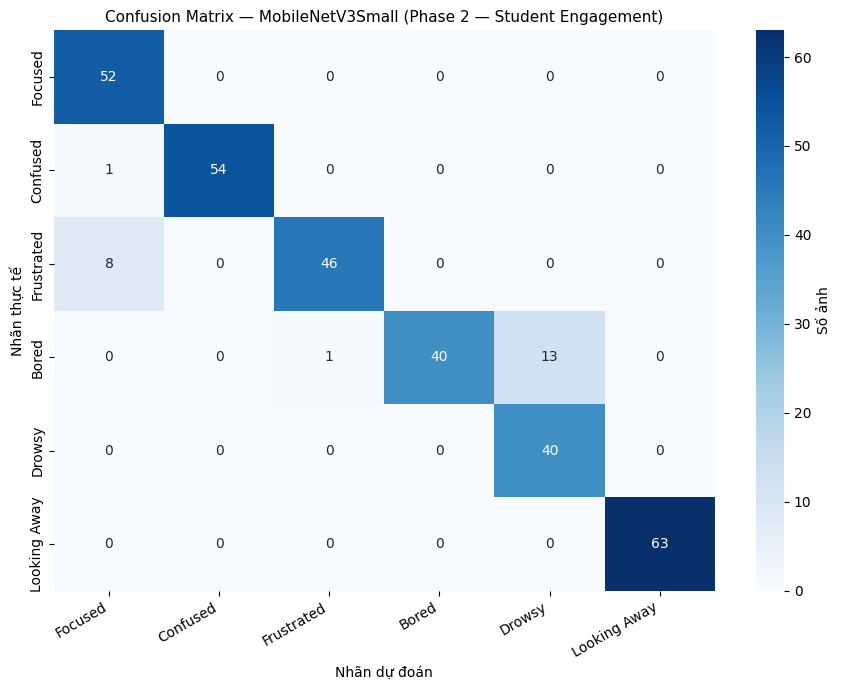

✅ Đã lưu: /content/drive/MyDrive/ProjectBTL/BTL/results/mobilenetv3_confusion_matrix.png


In [20]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ── Dự đoán trên test set ────────────────────────────────────────
y_true, y_pred = [], []
for images, labels in test_student:
    preds = model_p2.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))
y_true, y_pred = np.array(y_true), np.array(y_pred)

# ── Classification report ────────────────────────────────────────
label_names = ['Focused', 'Confused', 'Frustrated',
                'Bored', 'Drowsy', 'Looking Away']
report = classification_report(
    y_true, y_pred,
    target_names=label_names,
    output_dict=True
)
print(classification_report(y_true, y_pred, target_names=label_names))

# ── Lưu JSON metrics ─────────────────────────────────────────────
metrics = {
    'model': 'MobileNetV3Small',
    'phase1_best_val_acc': float(max(history_p1_unfreeze.history['val_accuracy'])),
    'phase2_accuracy':     float(report['accuracy']),
    'macro_f1':            float(report['macro avg']['f1-score']),
    'precision':           float(report['macro avg']['precision']),
    'recall':              float(report['macro avg']['recall']),
    'per_class_f1': {
        name: float(report[name]['f1-score']) for name in label_names
    },
    'per_class_precision': {
        name: float(report[name]['precision']) for name in label_names
    },
    'per_class_recall': {
        name: float(report[name]['recall']) for name in label_names
    },
}
with open(f'{RESULTS_DIR}/mobilenetv3_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print(f"\n✅ Đã lưu: {RESULTS_DIR}/mobilenetv3_metrics.json")

# ── Vẽ confusion matrix ──────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_names, yticklabels=label_names,
    cbar_kws={'label': 'Số ảnh'}
)
plt.title('Confusion Matrix — MobileNetV3Small (Phase 2 — Student Engagement)',
          fontsize=11)
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/mobilenetv3_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Đã lưu: {RESULTS_DIR}/mobilenetv3_confusion_matrix.png")

## Bonus — Visualize training curves

Vẽ accuracy/loss qua các epoch để đưa vào báo cáo.

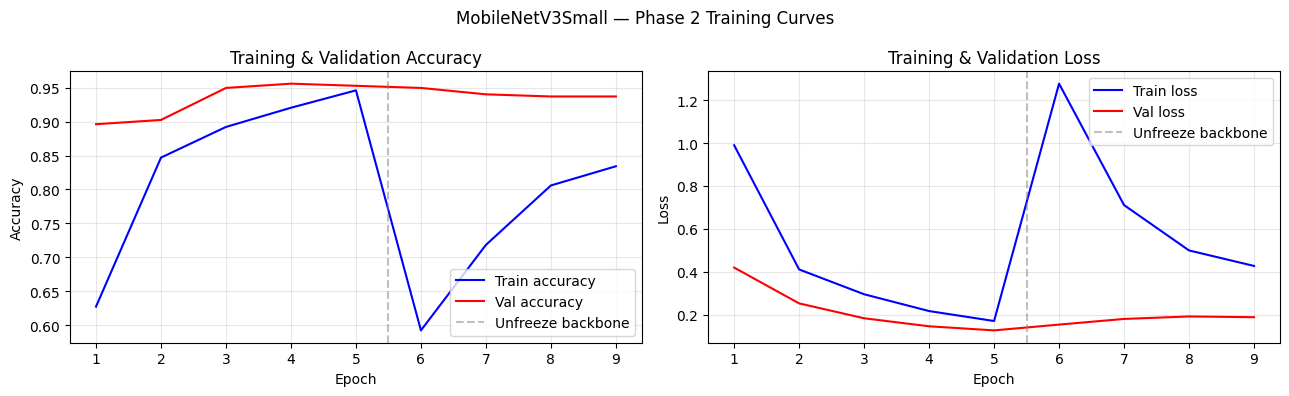

✅ Đã lưu: /content/drive/MyDrive/ProjectBTL/BTL/results/mobilenetv3_training_curves.png


In [21]:
# Ghép history Phase 2 freeze + unfreeze
acc_train = (history_p2_freeze.history['accuracy'] +
             history_p2_unfreeze.history['accuracy'])
acc_val   = (history_p2_freeze.history['val_accuracy'] +
             history_p2_unfreeze.history['val_accuracy'])
loss_train = (history_p2_freeze.history['loss'] +
              history_p2_unfreeze.history['loss'])
loss_val   = (history_p2_freeze.history['val_loss'] +
              history_p2_unfreeze.history['val_loss'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, len(acc_train) + 1)

axes[0].plot(epochs, acc_train, 'b-', label='Train accuracy')
axes[0].plot(epochs, acc_val,   'r-', label='Val accuracy')
axes[0].axvline(x=5.5, color='gray', linestyle='--', alpha=0.5,
                label='Unfreeze backbone')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training & Validation Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, loss_train, 'b-', label='Train loss')
axes[1].plot(epochs, loss_val,   'r-', label='Val loss')
axes[1].axvline(x=5.5, color='gray', linestyle='--', alpha=0.5,
                label='Unfreeze backbone')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Training & Validation Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('MobileNetV3Small — Phase 2 Training Curves', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/mobilenetv3_training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Đã lưu: {RESULTS_DIR}/mobilenetv3_training_curves.png")

---
## ✅ Hoàn thành — Checklist nộp

Sau khi chạy xong, kiểm tra các file đã được tạo:

| File | Vị trí |
|------|--------|
| ✅ `mobilenetv3_phase1.h5` | `BTL/weights/` |
| ✅ `mobilenetv3_phase2.h5` | `BTL/weights/` |
| ✅ `mobilenetv3_metrics.json` | `BTL/results/` |
| ✅ `mobilenetv3_confusion_matrix.png` | `BTL/results/` |
| ✅ `mobilenetv3_training_curves.png` | `BTL/results/` |

**Việc còn lại (Word — không có trong notebook này):**
- Viết mục 3.4.1 — mô tả MobileNetV3 (Depthwise Separable Conv, Hard-Swish)
- Gửi số liệu accuracy + macro F1 cho Người 5 để điền vào bảng 4.2.1
- Phân tích confusion matrix → đưa vào mục 4.2.2